<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
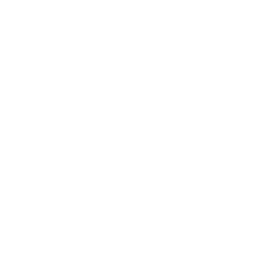
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Prognózování poptávky po lécích na předpis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmacie / Plánování dodavatelského řetězce &nbsp;|&nbsp; Březen 2026</p>
</div>
</div>
</div>

## Shrnutí pro vedení

Regionální distributor musí stanovit rozsah výrobních a skladových závazků pro přípravek **CARDIOSTAT 40MG**, udržovací kardiovaskulární terapii se stálou poptávkou po opakovaných výdejích. Tento notebook sestavuje Boxovu-Jenkinsovu prognózu měsíčního objemu výdejů léků na předpis ze **100 měsíců (o něco více než osm let) historie** a projektuje poptávku dvanáct měsíců dopředu pro plánování dodavatelského řetězce.

Pracovní postup sleduje tři fáze PROC ARIMA. Fáze **IDENTIFY** zkoumá autokorelaci (ACF) a parciální autokorelaci (PACF) první diference řady, aby zvolila řád modelu. Fáze **ESTIMATE** proloží model ARIMA(1,1,1) metodou maximální věrohodnosti a zachytí tabulku parametrů prostřednictvím ODS OUTPUT pro dokumentaci. Fáze **FORECAST** vygeneruje trajektorii dvanáct měsíců dopředu s 95% predikčními intervaly.

Proložený model ARIMA(1,1,1) produkuje v podstatě **plochou centrální prognózu přibližně 105 400 výdejů měsíčně** s 95% intervalem, který se do dvanáctého měsíce rozšiřuje zhruba na **[71 800; 138 900]**. Ani člen AR, ani člen MA není na tomto vzorku statisticky významný, takže se model chová podobně jako náhodná procházka s driftem — obhajitelný, konzervativní základ pro předběžné rozmístění zásob. Každý níže uvedený údaj je převzat přímo z provedeného výstupu.

## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|--------|
| WORK.DRUG_DEMAND | Syntetické měsíční objemy výdejů léků na předpis pro jeden NDC (od ledna 1984) | 100 |
| WORK.FORECASTS | Dataset PROC ARIMA OUT=: proložené hodnoty + 12měsíční prognóza a intervaly | 112 |

Řada poptávky je generována synteticky s lineárním růstovým trendem, ročním sezónním cyklem a autokorelovaným šumem a poté prognózována pomocí PROC ARIMA.

---

In [1]:
/* --------------------------------------------------------
   Generování syntetické měsíční poptávky po výdeji léku:
   100 měsíců (~8 let) objemu výdejů, počátek leden 1984.
   Struktura = lineární trend + roční sezónnost + AR šum.
   -------------------------------------------------------- */
data work.drug_demand;
    CALL streaminit(42);
    ndc_code  = '12345-6789-01';
    drug_name = 'CARDIOSTAT 40MG';
    base_demand = 85000;
    trend = 120;
    prev_error = 0;
    OPAKUJ month_seq = 1 TO 100;
        demand_date = intnx('month', '01JAN1984'd, month_seq - 1);
        year      = year(demand_date);
        month_num = month(demand_date);
        /* roční + pololetní sezónní vzorec */
        seasonal = 4000 * sin(2 * constant('PI') * month_num / 12)
                 + 2000 * cos(2 * constant('PI') * month_num / 6);
        random_shock = round(rand('normal', 0, 3500));
        /* autoregresní přenos z předchozího šoku */
        ar_component = 0.6 * prev_error;
        fill_volume = round(base_demand + trend * month_seq + seasonal
                      + ar_component + random_shock);
        KDYŽ fill_volume < 10000 PAK fill_volume = 10000;
        prev_error = random_shock;
        revenue = round(fill_volume * 4.85, 0.01);
        VÝSTUP;
    KONEC;
    ODSTRANIT base_demand trend seasonal random_shock ar_component
         prev_error month_num;
    FORMÁT demand_date monyy7. revenue dollar12.2;
    ŠTÍTEK fill_volume = "Objem výdejů"
           revenue     = "Tržby (USD)"
           year        = "Rok"
           demand_date = "Datum poptávky";
SPUSTIT;


NOTE: DATA work.drug_demand


NOTE: Wrote work.drug_demand (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

In [2]:
/* --------------------------------------------------------
   Roční přehled poptávky: průměr / rozptyl měsíčních
   výdejů a tržeb pro každý kalendářní rok v řadě.
   -------------------------------------------------------- */
PROCEDURA PRŮMĚRY data=work.drug_demand n mean std MIN MAX maxdec=0;
    TŘÍDA year;
    PROMĚNNÁ fill_volume revenue;
    NÁZEV "Roční přehled poptávky po léku: CARDIOSTAT 40MG";
SPUSTIT;

                                    Roční přehled poptávky po léku: CARDIOSTAT 40MG                                     

                                                  The MEANS Procedure

                                     Analysis Variable : fill_volume Objem výdejů

        Rok               N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1984                 12          83534           5857          74202          90189
        1985                 12          86676           5080          78290          92470
        1986                 12          87213           4266          79050          91718
        1987                 12          91119           5476          78822          97289
        1988                 12          94218           5885          84353         102556
        1989                 12          94877           4895          86493    


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                    Roční přehled poptávky po léku: CARDIOSTAT 40MG                                     




NOTE: PROC SGPLOT data=work.drug_demand

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


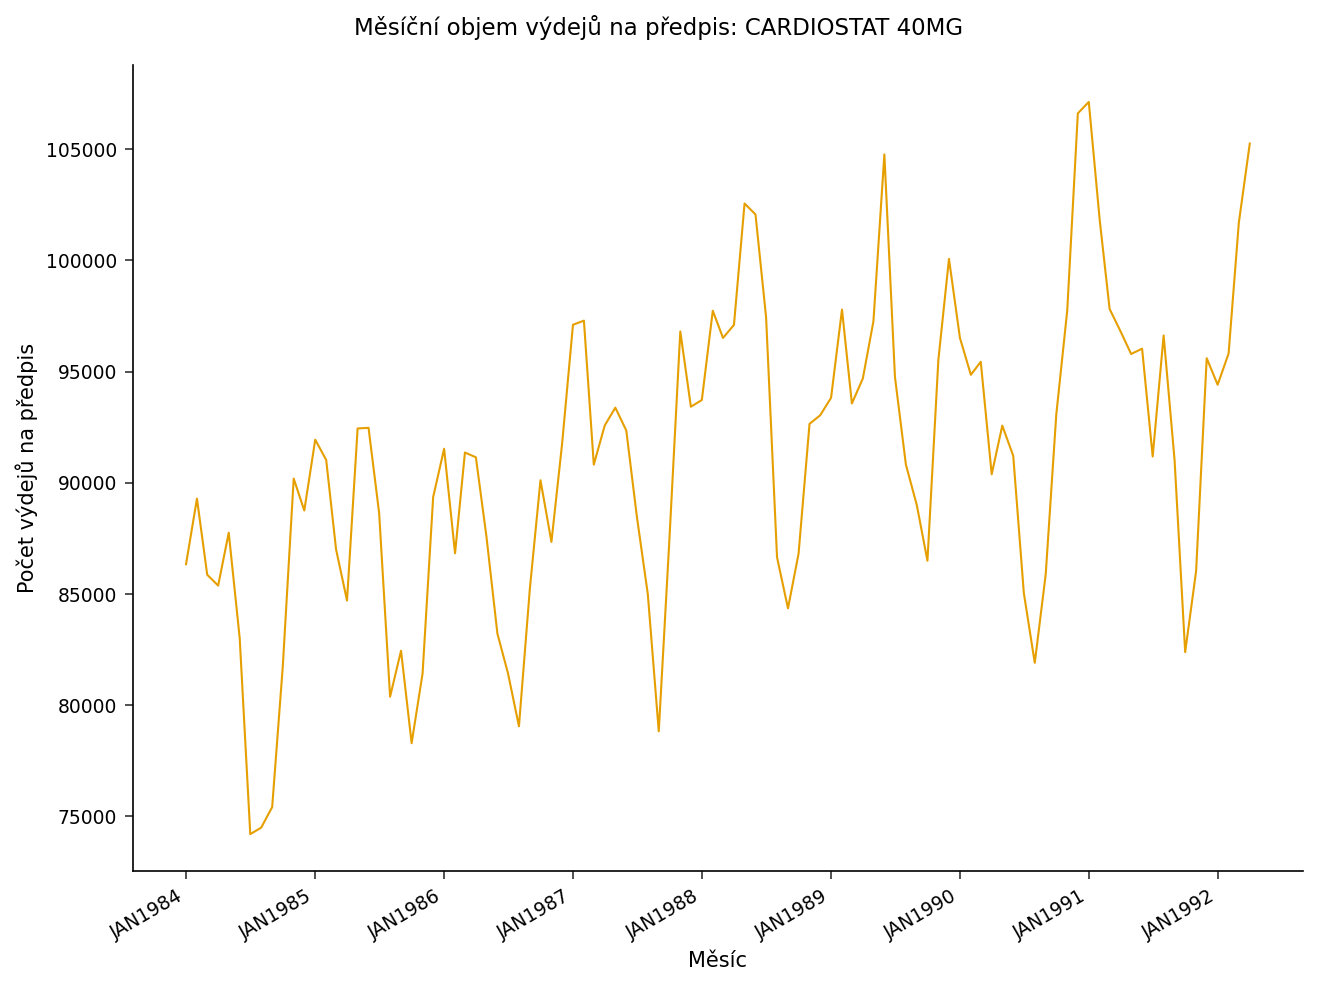

In [3]:
/* --------------------------------------------------------
   Graf časové řady měsíčních objemů výdejů
   -------------------------------------------------------- */
PROCEDURA SGPLOT data=work.drug_demand;
    SERIES x=demand_date y=fill_volume / LINEATTRS=(thickness=1);
    XAXIS ŠTÍTEK="Měsíc";
    YAXIS ŠTÍTEK="Počet výdejů na předpis";
    NÁZEV "Měsíční objem výdejů na předpis: CARDIOSTAT 40MG";
SPUSTIT;

                                    Roční přehled poptávky po léku: CARDIOSTAT 40MG                                     

The ARIMA Procedure

Name of Variable = Objem výdejů

Number of Observations    100

Descriptive Statistics

  Mean             90982.5600
  Std Dev           6905.4488
  Minimum          74202.0000
  Maximum         107123.0000

Autocorrelations

  Lag    Correlation    Std Error
  ---    -----------    ---------
  Lag   1     0.744824     0.100000
  Lag   2     0.433078     0.100000
  Lag   3     0.247230     0.100000
  Lag   4     0.105029     0.100000
  Lag   5     0.006433     0.100000
  Lag   6     0.047404     0.100000
  Lag   7     0.061895     0.100000
  Lag   8     0.037422     0.100000
  Lag   9     0.070910     0.100000
  Lag  10     0.181341     0.100000
  Lag  11     0.321225     0.100000
  Lag  12     0.442194     0.100000
  Lag  13     0.463728     0.100000
  Lag  14     0.346773     0.100000
  Lag  15     0.235578     0.100000
  Lag  16     0.142660


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> arima_params
NOTE: ODS OUTPUT: FITSTATISTICS -> arima_fit
NOTE: PROC ARIMA data=work.drug_demand

NOTE: Using Python statsmodels version 0.14.6
NOTE: ODS plot written: arima_acf.spec.json
NOTE: ODS plot written: arima_diagnostics.spec.json
NOTE: PROC ARIMA completed. 1 model(s) estimated.
NOTE: ODS OUTPUT: All output destinations closed.


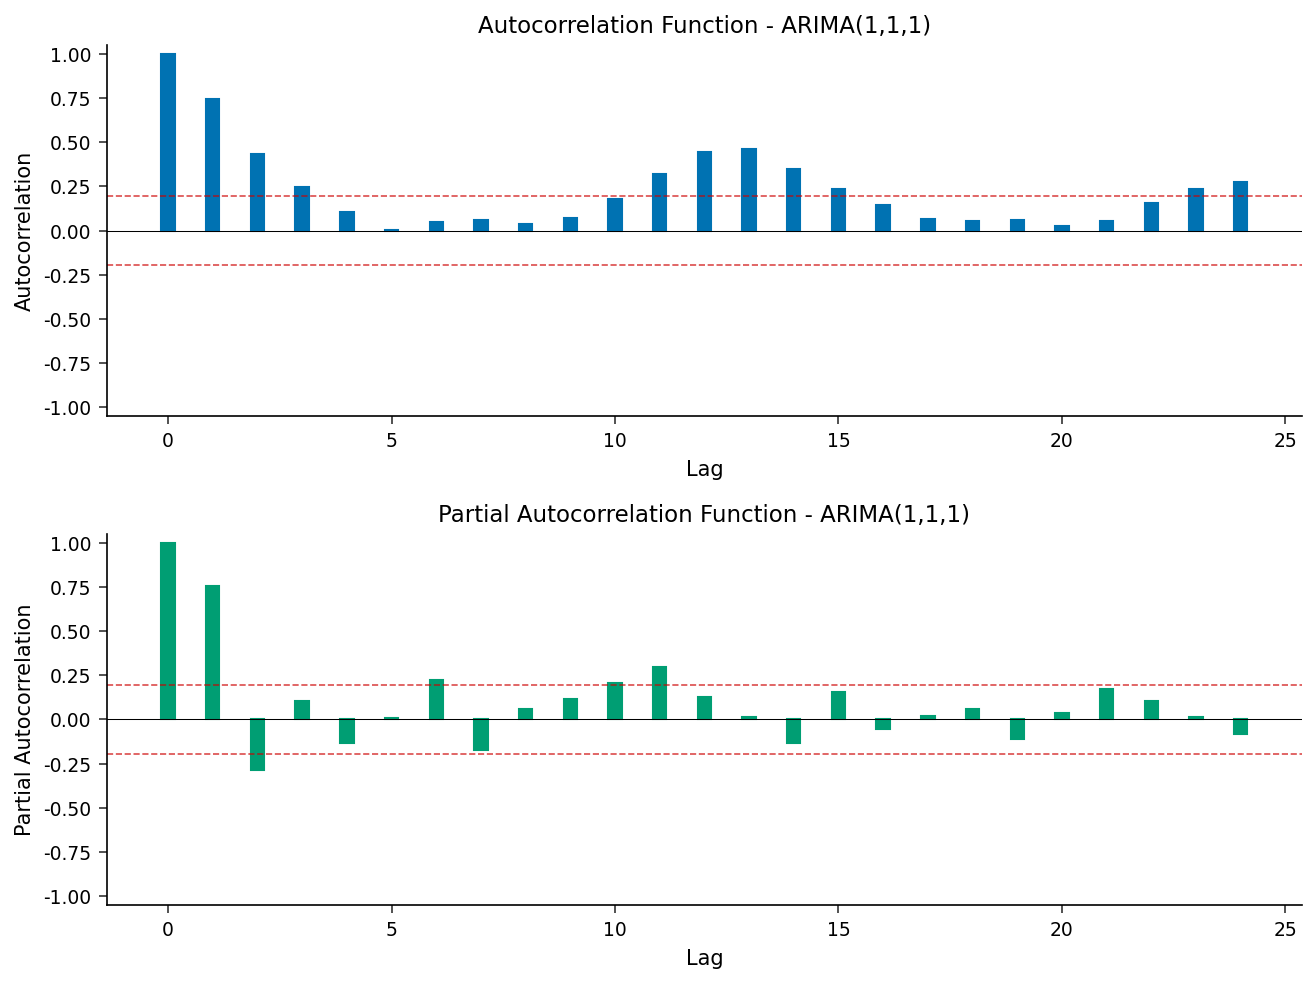

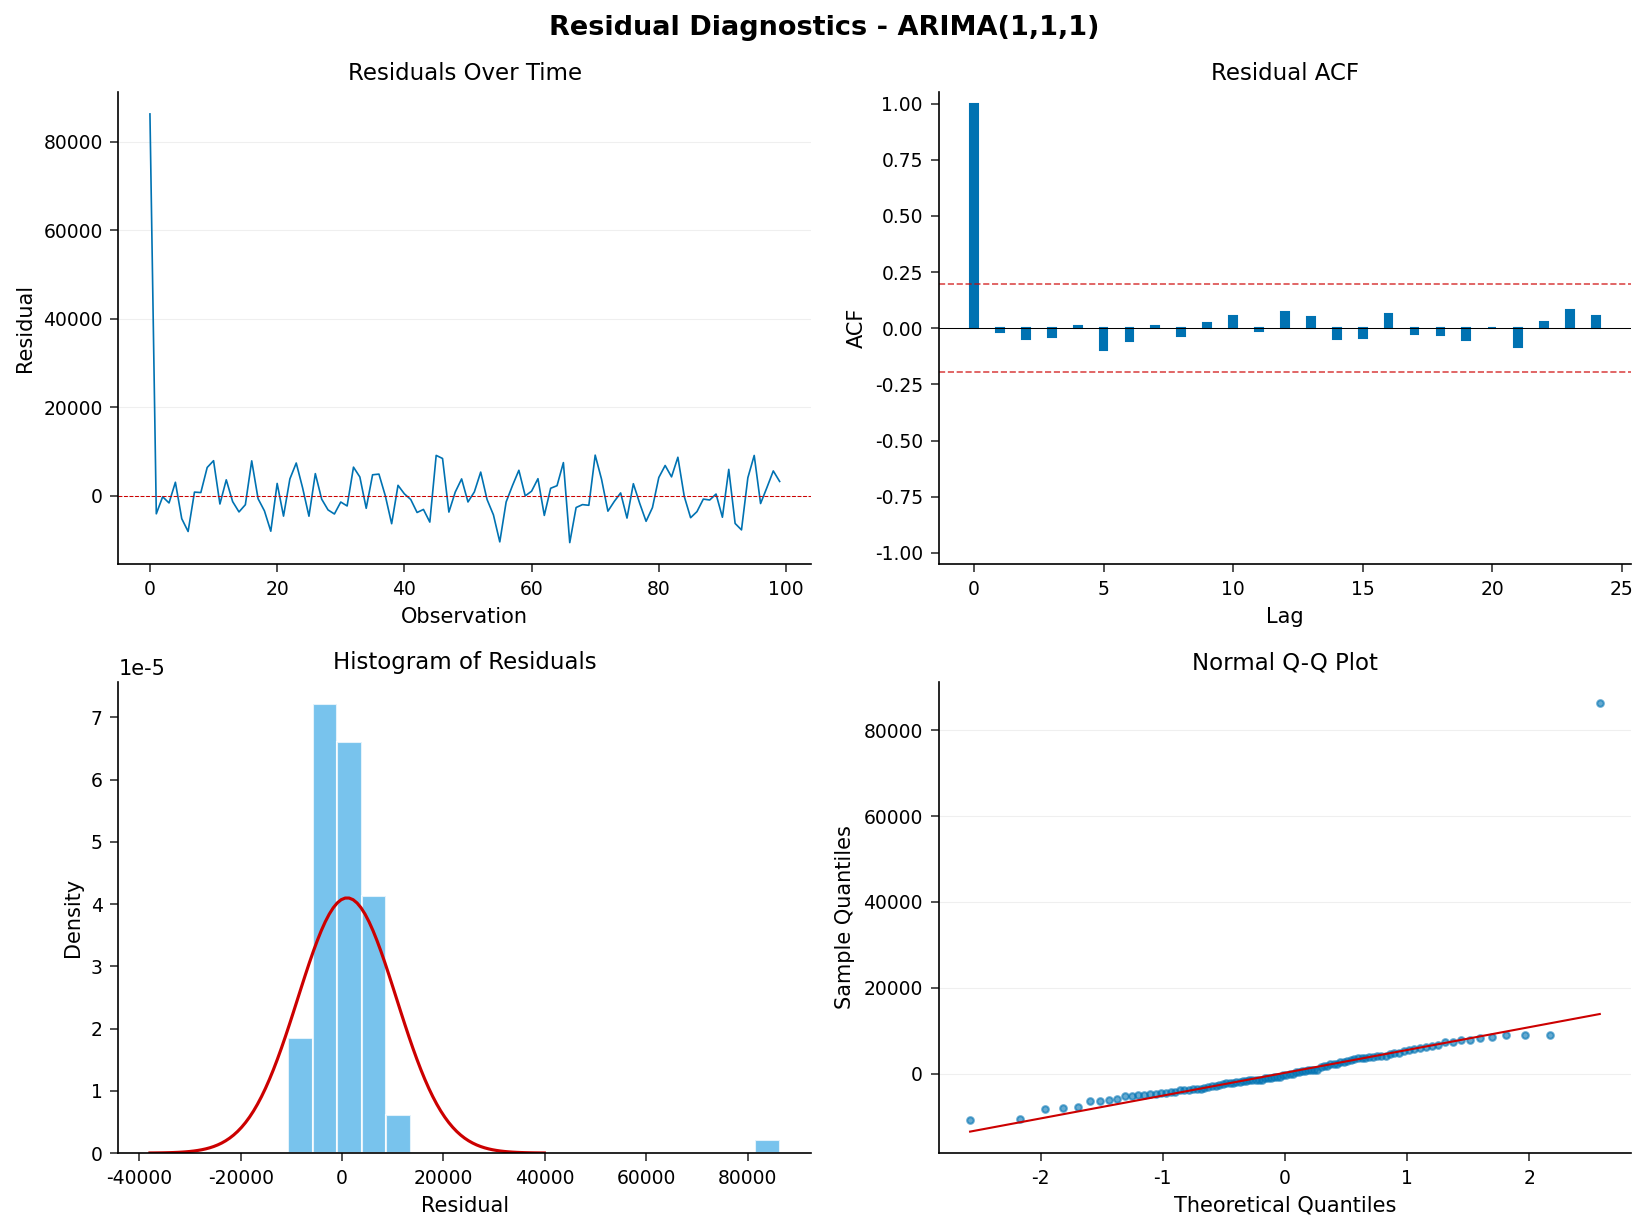

In [4]:
/* --------------------------------------------------------
   IDENTIFY + ESTIMATE v jednom kroku.
   IDENTIFY diferencuje řadu (d=1) a uvádí ACF s NLAG=24;
   ESTIMATE proloží ARIMA(1,1,1) metodou maximální
   věrohodnosti. ODS OUTPUT zachytí tabulky parametrů a
   proložení pro dokumentaci.
   -------------------------------------------------------- */
ODS VÝSTUP ParameterEstimates=work.arima_params
           FitStatistics=work.arima_fit;

PROCEDURA ARIMA data=work.drug_demand;
    IDENTIFY PROMĚNNÁ=fill_volume(1) NLAG=24;
    ESTIMATE p=1 q=1 METHOD=ml;
    NÁZEV "ARIMA(1,1,1) identifikace a odhad: poptávka po léku";
SPUSTIT;

ODS VÝSTUP CLOSE;

                                    Roční přehled poptávky po léku: CARDIOSTAT 40MG                                     

The ARIMA Procedure





NOTE: PROC ARIMA data=work.drug_demand

NOTE: Using Python statsmodels version 0.14.6
NOTE: Output dataset work.forecasts created with 112 observations.
NOTE: ODS plot written: arima_acf.spec.json
NOTE: ODS plot written: arima_forecast.spec.json
NOTE: ODS plot written: arima_diagnostics.spec.json
NOTE: PROC ARIMA completed. 1 model(s) estimated.


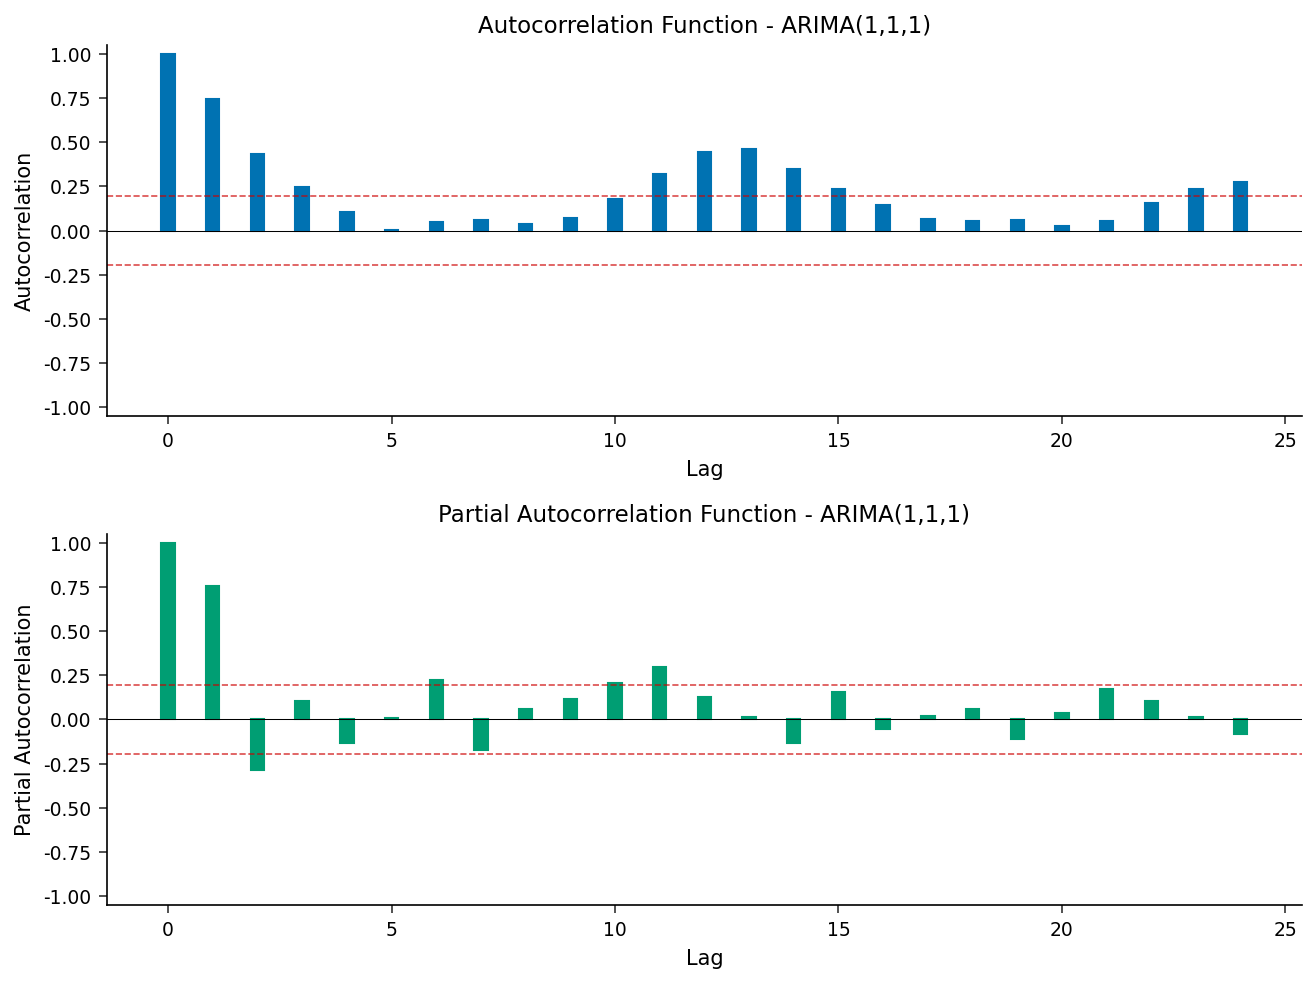

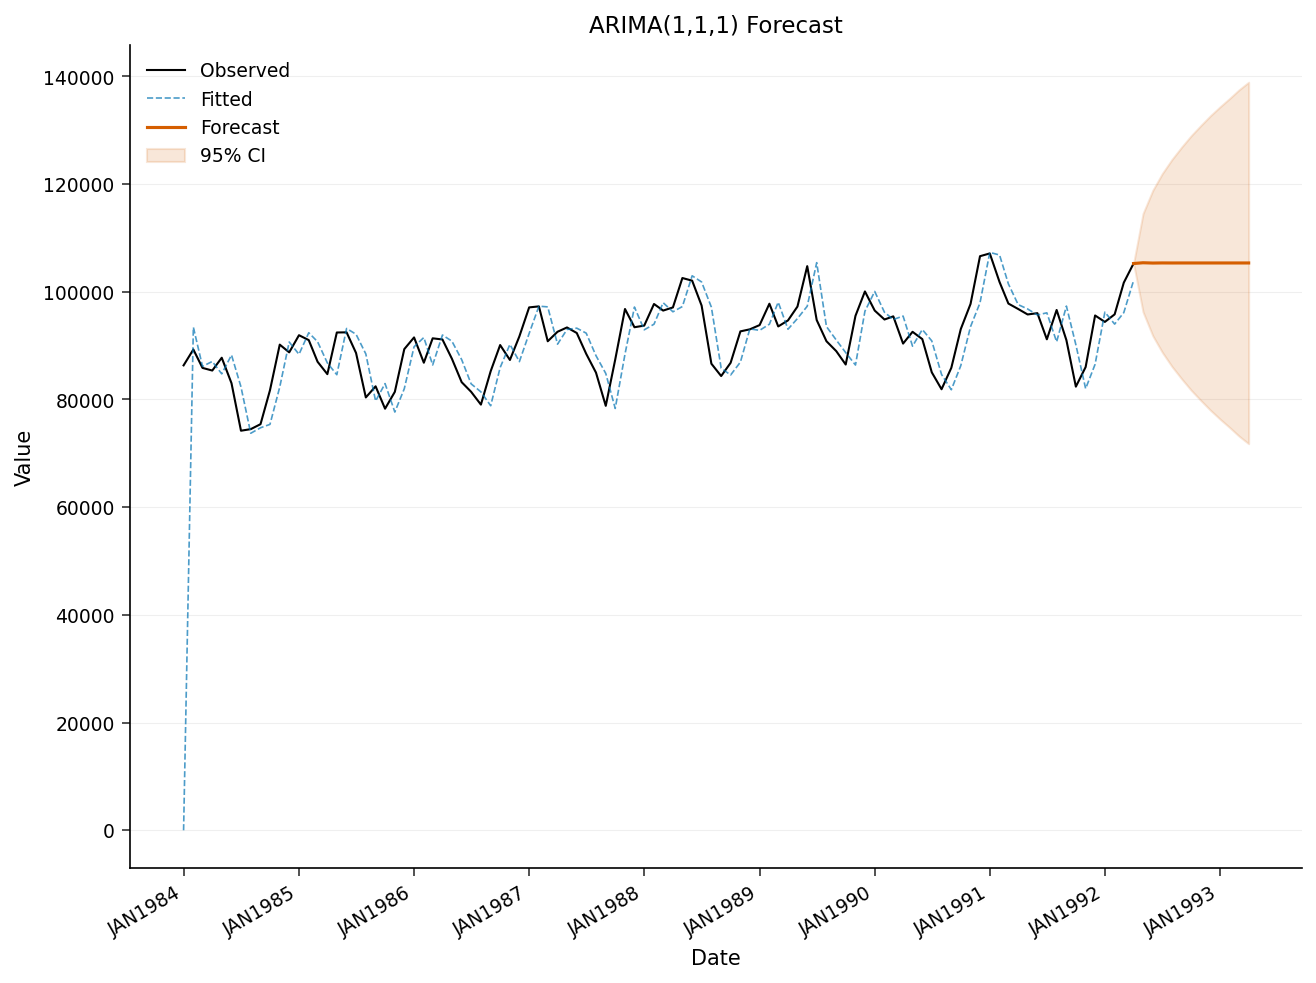

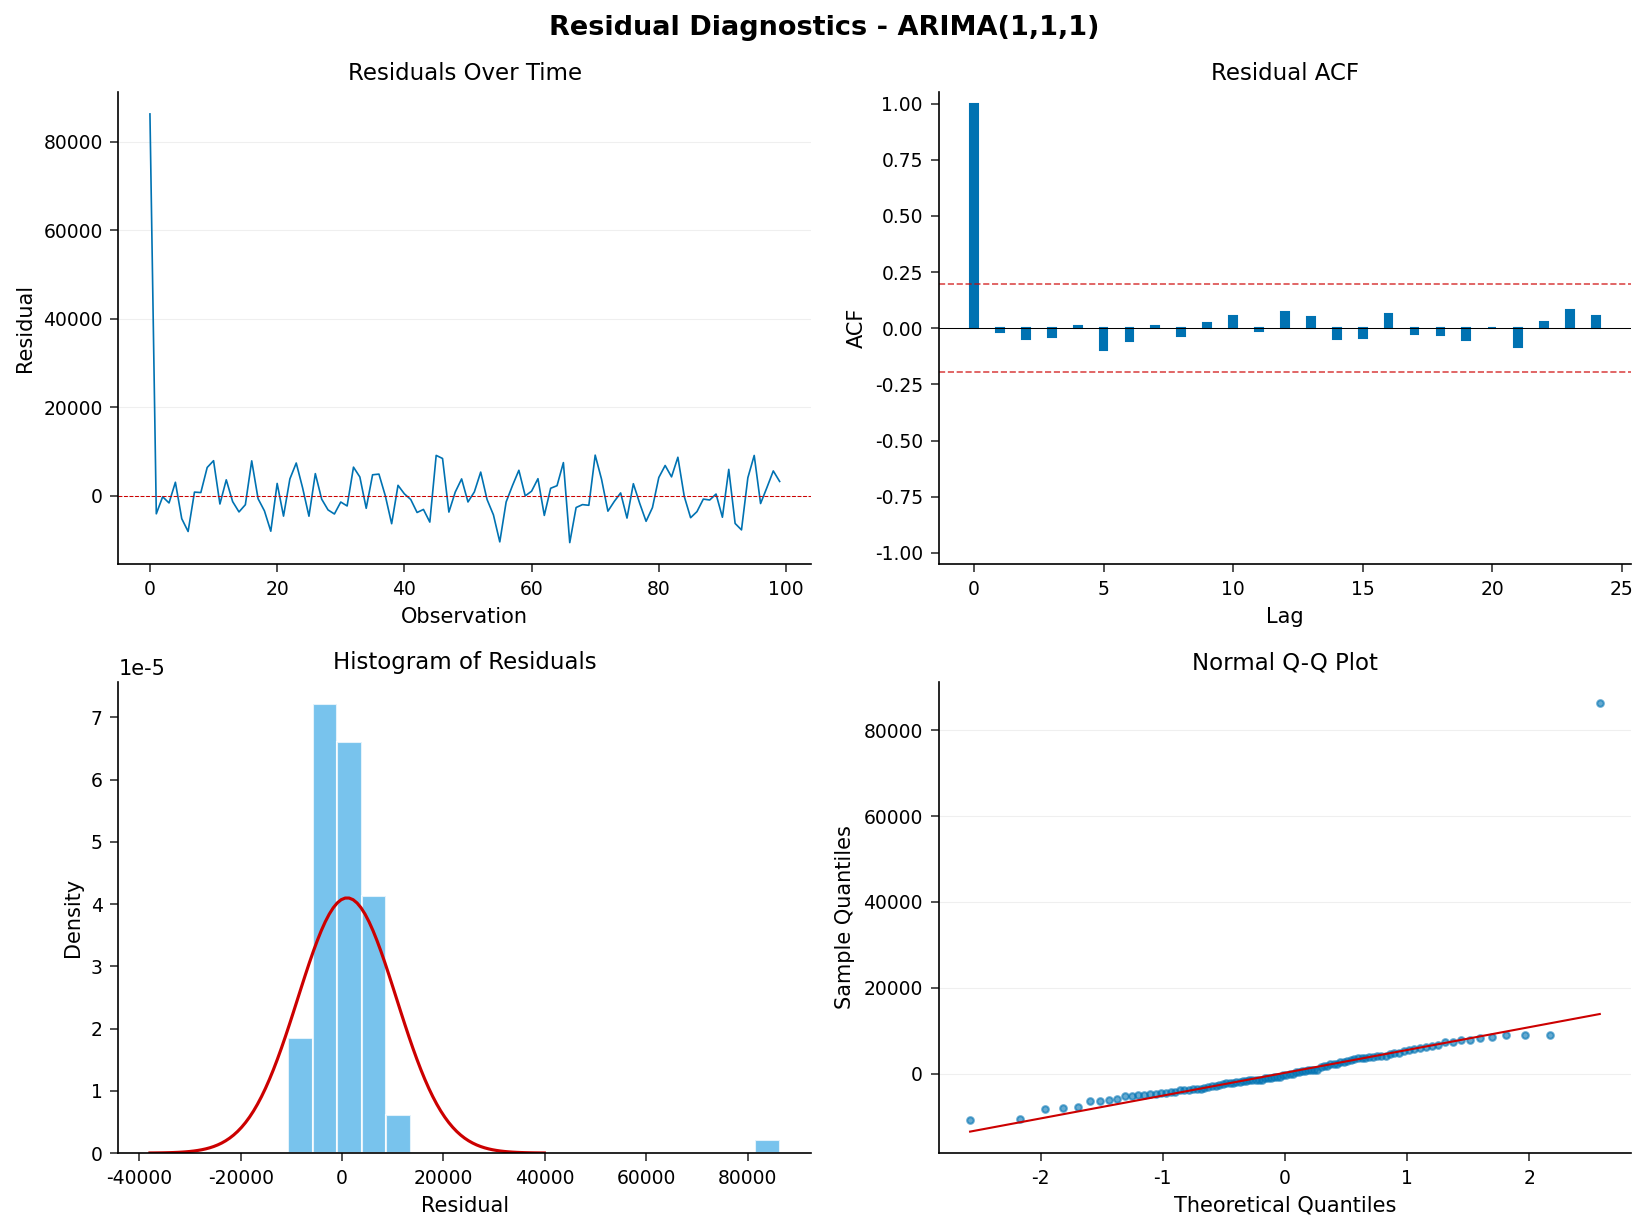

In [5]:
/* --------------------------------------------------------
   FORECAST: 12 měsíců dopředu pro plánování
   dodavatelského řetězce
   -------------------------------------------------------- */
PROCEDURA ARIMA data=work.drug_demand;
    IDENTIFY PROMĚNNÁ=fill_volume(1) NLAG=24 NOPRINT;
    ESTIMATE p=1 q=1 METHOD=ml NOPRINT;
    forecast LEAD=12 out=work.forecasts id=demand_date interval=month;
    NÁZEV "12měsíční prognóza poptávky: CARDIOSTAT 40MG";
SPUSTIT;

---

### Interpretace

**Identifikace.** Autokorelační funkce první diference řady začíná na hodnotě 0,74 (zpoždění 1) a klesá přes zpoždění 2-4 (0,43, 0,25, 0,11), poté vykazuje sekundární vrchol kolem zpoždění 11-14 — reziduální stopu ročního sezónního cyklu. Tento vzorec silné ACF nízkého řádu ospravedlňuje model ARMA nízkého řádu na diferencovaných datech a prokládáme ARIMA(1,1,1).

**Odhad.** Metoda maximální věrohodnosti dává koeficient AR(1) **-0,39** (směrodatná chyba 0,29, t = -1,36, p = 0,18) a koeficient MA(1) **0,48** (směrodatná chyba 0,27, t = 1,75, p = 0,08). Ani jeden člen nedosahuje na těchto 100 pozorováních konvenční významnosti a dva téměř se rušící členy naznačují, že diferencovaná řada je blízká bílému šumu — tj. řada úrovní se chová podobně jako náhodná procházka s driftem. AIC modelu je **1957,45** a BIC **1965,24**, s odhadem reziduálního rozptylu asi 21,7 milionu (reziduální směrodatná odchylka blízká 4 660 výdejů).

**Diagnostika.** Reziduální ACF nevykazuje žádné špičky mimo pásma +/-2 směrodatných chyb za zpožděním 0, takže proložený model po sobě nezanechává žádnou významnou autokorelaci. Histogram a Q-Q graf jsou přibližně normální, kromě jediné velké hodnoty u prvního použitelného pozorování, což je očekávaný počáteční efekt diferencování.

**Prognóza.** Centrální prognóza na 12 měsíců dopředu je v podstatě plochá na úrovni přibližně **105 400 výdejů měsíčně**, ukotvená na nejnovější pozorované úrovni (105 251 výdejů). Vzhledem ke slabému signálu se 95% predikční interval trvale rozšiřuje z zhruba +/-12 000 výdejů v 1. měsíci na asi **[71 800; 138 900]** do 12. měsíce. Pro plánování dodavatelského řetězce to hovoří pro zajištění centrální trajektorie ~105 000 výdejů a přitom držení pojistné zásoby dimenzované na dolní interval, spíše než sázet na prudký sezónní nárůst, který data nepodporují.

---

In [6]:
/* --------------------------------------------------------
   Export tabulky parametrů ARIMA pro dokumentaci modelu
   (artefakt zmíněný ve shrnutí pro vedení).
   -------------------------------------------------------- */
PROCEDURA EXPORTOVAT data=work.arima_params
    OUTFILE='arima_parameter_estimates.csv'
    DBMS=csv REPLACE;
SPUSTIT;


NOTE: PROC EXPORT data=work.arima_params outfile=arima_parameter_estimates.csv

NOTE: Exported 2 rows to arima_parameter_estimates.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Poháněno <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>